# 🧭 Build Your Own Theory — a guided tutorial

This notebook walks you, step by step, from a **stochastic differential equation** to its
**correlation functions** — building the theory in code with the `TheoryBuilder`, then
running the full Daedalus pipeline on it.

By the end you will have:

1. learned the *one* idea behind the MSR–JD formalism (it takes five minutes),
2. built a real, working theory line by line, and
3. run it through the pipeline (mean field → Feynman diagrams → cumulants) and plotted the result.

> **No simulation here.** This notebook is the *theory* path only: action → diagrams →
> analytic cumulants. For theory-vs-simulation overlays, see the notebooks in
> [`examples/`](examples/).

**Two ways to build a theory — this notebook uses the first:**

| | Code (this notebook) | Point-and-click |
|---|---|---|
| how | type `TheoryBuilder(...)` calls | fill a form in [`theory_builder.ipynb`](theory_builder.ipynb) |
| best for | learning what each piece *means*; scripting | quick declaration, no code |

No prior experience with the codebase is assumed — just run the cells top to bottom.

## 0. Setup

Run this once. It puts the repository on the import path and pulls in the two things you
need: the **builder** (to declare a theory) and **`daedalus`** (the run / summary / plot
front-end).

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt

# Find the repo root (walk up until the 'pipeline' package appears) and add it to the path.
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))

import daedalus as dd                                       # run / summary / plot front-end
from pipeline.theory import TemporalTheoryBuilder, SpatialTheoryBuilder
print('daedalus →', dd.REPO_ROOT)

daedalus → /Users/matthewszuromi/Documents/Education/BU PhD/Ocker Lab/Automated Feynman Calculations


## 1. The one idea: an *action*

Every theory in Daedalus is specified by an **action** — a single expression the pipeline
differentiates to read off propagators and interaction vertices. Translating your model
into an action is the only real *thinking* step, and it follows a fixed recipe.

Start from a **Langevin equation** (a stochastic ODE/SDE):

$$\dot x \;=\; f(x) \;+\; \xi, \qquad \langle\, \xi(t)\,\xi(t')\,\rangle \;=\; 2D\,\delta(t-t').$$

The **MSR–JD** construction (Martin–Siggia–Rose / Janssen–De Dominicis) introduces, for
every physical field $x$, a partner **response field** $\tilde x$, and writes

$$S \;=\; \int\! dt\;\Big[\; \underbrace{\tilde x\,\big(\dot x - f(x)\big)}_{\text{equation of motion}}
\;-\; \underbrace{D\,\tilde x^{2}}_{\text{noise}} \;\Big].$$

That is the whole recipe — two moves:

1. **Move the dynamics to one side** so the bracket reads *(left-hand side) − (right-hand side) = 0*,
   and multiply it by the response field $\tilde x$.
2. **Add a noise term** $-D\,\tilde x^{2}$ — one per independent white-noise source ($2D$ is its strength).

The pipeline does everything after that.

## 2. The builder, in six moves

You hand the builder those same pieces, in this order:

| move | call | what it does |
|---|---|---|
| **start** | `TemporalTheoryBuilder('name')` | a time-only (ODE/SDE) theory. *(PDEs use `SpatialTheoryBuilder` — Appendix A.)* |
| **group** | `.population('pop', size=1)` | a set of identical units; `size=1` is a plain scalar |
| **field** | `.physical_field('x', population='pop')` | your field `x`. **Auto-creates** the response field `xt` and the mean-field saddle `xstar` |
| **constants** | `.parameter('mu', default=1.0, domain='positive')` | a named parameter with a default value |
| **action** | `.set_action_text('...')` | the MSR–JD action from §1, written as text |
| **EOM** | `.equation(lhs='...', rhs='...', population='pop')` | the deterministic equation of motion $\dot x = f(x)$, used to solve the mean field |

Finish with `.build()` → a `model` dictionary you can run.

**Action-text syntax** (Sage/Python-like):

- the field is `x[i]`; its response partner is `xt[i]`; the index `[i]` runs over the population
- `Dt` is the time-derivative operator $\partial_t$ — e.g. `(Dt+mu)*x[i]`
- `^` is a power: `x[i]^3` means $x^3$
- wrap the per-unit action in `sum( ... for i in pop )` to sum over the population

## 3. Worked example: the quartic OU process

Let's build the simplest *nonlinear* stochastic process — an Ornstein–Uhlenbeck variable
with a cubic restoring force:

$$\dot x \;=\; -\mu\,x \;-\; \varepsilon\,x^{3} \;+\; \xi, \qquad \langle\xi\xi\rangle = 2D\,\delta.$$

Apply the recipe:

- $f(x) = -\mu x - \varepsilon x^{3}$
- equation-of-motion bracket: $\dot x - f(x) = \dot x + \mu x + \varepsilon x^{3} = (\partial_t+\mu)\,x + \varepsilon x^{3}$
- action: $\;S = \tilde x\big[(\partial_t+\mu)x + \varepsilon x^{3}\big] - D\,\tilde x^{2}$

In builder syntax that action is

```
sum( xt[i]*((Dt+mu)*x[i] + eps*x[i]^3) - D*xt[i]^2  for i in pop )
```

Here is the whole theory, with each line tied back to the math:

In [2]:
model = (
    TemporalTheoryBuilder('Quartic OU process')
    .population('pop', size=1)                            # one scalar unit
    .physical_field('x', population='pop',                # the field x  (auto: response xt, saddle xstar)
                    description='the state variable')
    .parameter('mu',  default=1.0,  domain='positive')    # linear relaxation rate
    .parameter('eps', default=0.05, domain='positive')    # cubic nonlinearity strength
    .parameter('D',   default=1.0,  domain='positive')    # noise strength  (<xi xi> = 2 D delta)
    # --- the MSR-JD action (the recipe from section 1, written out) ---
    .set_action_text(
        'sum( xt[i]*((Dt+mu)*x[i] + eps*x[i]^3) - D*xt[i]^2  for i in pop )')
    # --- the deterministic equation of motion (used for the mean-field solve) ---
    .equation(lhs='(Dt+mu)*x[i]', rhs='-eps*x[i]^3', population='pop')
    .build()
)
print('built:', model['name'], '| fields:', dd.field_names(model))

built: Quartic OU process | fields: ['dx']


## 4. Look at what you built

`describe_model` prints the structure the pipeline parsed out of your action — the fields,
their response partners, the parameters, the mean-field saddle it will solve, and the
governing equation. A good sanity check before running.

In [3]:
dd.describe_model(model);    # trailing ';' = print once, don't echo the returned string

────────────────────────────────────────────────────────────────────────
  Quartic OU process
────────────────────────────────────────────────────────────────────────
Domain         : temporal ODE (time-only)
Fields         : x — the state variable
Response fields: xt
Parameters     :
    mu = 1.00000000000000  (positive)
    eps = 0.0500000000000000  (positive)
    D = 1.00000000000000  (positive)
Mean-field saddle (solved by the pipeline): xstar
Governing eqn  : (Dt+mu)*x[i] = -eps*x[i]^3


## 5. Configure and run

One `dd.Config` holds the whole run. The two knobs you'll touch most:

- **`k`** — correlator order. `k=2` is the two-point function $\langle x\,x\rangle$.
- **`max_ell`** — loop order. `0` = tree (mean-field level), `1` = + the 1-loop correction, …

**`external_fields`** says which fields sit on the correlator's legs. The pipeline works with
*fluctuations*, whose internal name is your field with a `d` prefix — so `x` → `dx` (this is
exactly what `dd.field_names` printed above). For $\langle x\,x\rangle$ that's
`[('dx', 1), ('dx', 1)]`.

`dd.run` then does the whole chain — solve the mean field → enumerate the Feynman diagrams →
integrate them — and returns the cumulant. **No simulation involved.**

In [4]:
cfg = dd.Config(
    k=2,                                      # two-point correlator <x x>
    max_ell=0,                                # 0 = tree; bump to 1 for the 1-loop correction
    external_fields=[('dx', 1), ('dx', 1)],   # both legs are the x-fluctuation (dx)
    tau_max=8.0, tau_step=0.5,                # time-lag grid for C(tau)
)
res = dd.run(model, cfg, None)                # mod=None: an inline-built model needs no theory file
print(dd.summary(res))

theory : 'Quartic OU process'
k      : 2    max_ell : 0
fields : ['dx']   spatial_dim : 0


## 6. Plot the cumulant

`dd.plot_cumulant` auto-dispatches on the theory — here it draws the temporal correlator
$C(\tau)$. With `max_ell \ge 1` it overlays each loop order so you can see the correction.

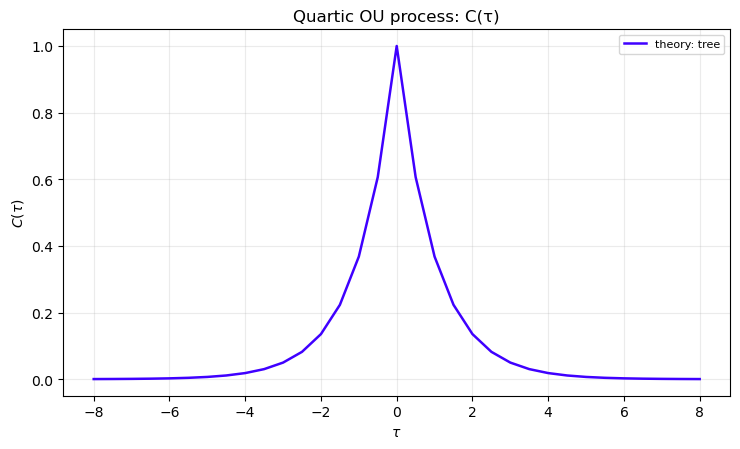

In [5]:
fig = dd.plot_cumulant(res, cfg, model)
plt.show()

---
# 🛠️ Now your turn

The cell below is a **working copy you can edit into your own theory**. As shipped it is a
quartic → **sextic** tweak of the example (restoring force $-\varepsilon x^{5}$ instead of
$-\varepsilon x^{3}$), so the notebook still runs end to end out of the box. Change the lines
marked `# <-- EDIT` into your model.

**Reminders**

- Recipe: action $= \tilde x\,[\dot x - f(x)] - D\,\tilde x^{2}$, i.e. `xt[i]*( ... ) - D*xt[i]^2`.
- Keep the nonlinearity consistent: the action carries $+\varepsilon x^{5}$ and the
  `equation` carries `rhs='-eps*x[i]^5'` — the action's force is *minus* the EOM's right-hand side.
- Start at `max_ell=0`, and keep `mu > 0` (a single potential well) for a clean first run.
- Want a PDE, extra fields, or memory kernels? See the appendices below.

In [6]:
my_model = (
    TemporalTheoryBuilder('My Theory')                    # <-- EDIT: name your theory
    .population('pop', size=1)
    .physical_field('x', population='pop',                # <-- EDIT: your field name
                    description='the state variable')
    .parameter('mu',  default=1.0,  domain='positive')    # <-- EDIT: your parameters
    .parameter('eps', default=0.05, domain='positive')
    .parameter('D',   default=1.0,  domain='positive')
    # <-- EDIT: your action.   f(x) = -mu*x - eps*x^5   ->   bracket  (Dt+mu)*x + eps*x^5
    .set_action_text(
        'sum( xt[i]*((Dt+mu)*x[i] + eps*x[i]^5) - D*xt[i]^2  for i in pop )')
    .equation(lhs='(Dt+mu)*x[i]', rhs='-eps*x[i]^5', population='pop')   # <-- EDIT: match the action
    .build()
)
dd.describe_model(my_model);

────────────────────────────────────────────────────────────────────────
  My Theory
────────────────────────────────────────────────────────────────────────
Domain         : temporal ODE (time-only)
Fields         : x — the state variable
Response fields: xt
Parameters     :
    mu = 1.00000000000000  (positive)
    eps = 0.0500000000000000  (positive)
    D = 1.00000000000000  (positive)
Mean-field saddle (solved by the pipeline): xstar
Governing eqn  : (Dt+mu)*x[i] = -eps*x[i]^5


## Run your theory

Same three steps as before — configure, run, plot.

theory : 'My Theory'
k      : 2    max_ell : 0
fields : ['dx']   spatial_dim : 0


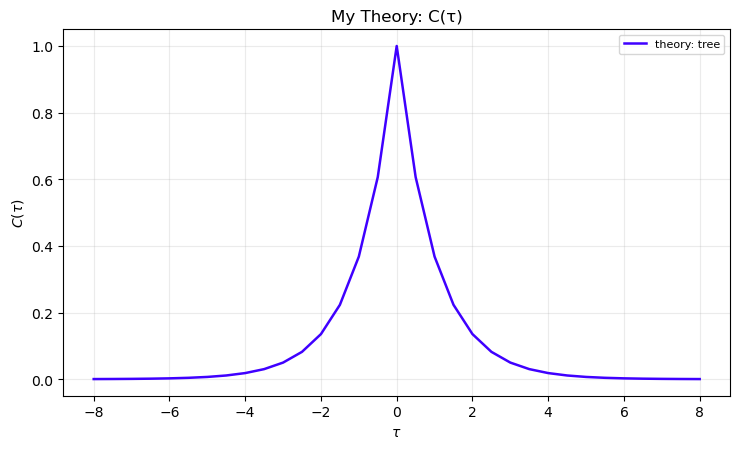

In [7]:
my_cfg = dd.Config(
    k=2, max_ell=0,
    external_fields=[('dx', 1), ('dx', 1)],   # <-- EDIT if you renamed the field (x -> dx)
    tau_max=8.0, tau_step=0.5,
)
my_res = dd.run(my_model, my_cfg, None)
print(dd.summary(my_res))

fig = dd.plot_cumulant(my_res, my_cfg, my_model)
plt.show()

---
## Appendix A — spatial (PDE) theories

A field that lives in space, $\phi(x,t)$, changes only three things versus the temporal case:

1. start with **`SpatialTheoryBuilder('name', n_populations=0)`** — a scalar field, so the
   action needs no `[i]` index and no `sum(...)`;
2. declare the field with a dimension: **`.physical_field('phi', spatial_dim=1)`** (1, 2, or 3).
   This registers a `Laplacian` symbol ($\nabla^{2}$) you can use in the action exactly like `Dt`;
3. add a **`.boundary('infinite')`** line.

Diffusion enters the equation-of-motion operator as $-D\nabla^{2}$. The Allen–Cahn $\phi^4$
field — $(\partial_t + \mu - D\nabla^{2})\phi + \lambda\phi^{3} = \eta$ — is below; edit it
the same way you edited §3. The spatial plot is the equal-time correlator $C(\chi,0)$ versus
separation $\chi = x_j - x_k$.

────────────────────────────────────────────────────────────────────────
  Allen-Cahn phi^4 (1D)
────────────────────────────────────────────────────────────────────────
Domain         : spatial PDE · d=1 · boundary=infinite · initial=stationary
Fields         : phi (x∈ℝ^1) — order parameter
Response fields: phit
Parameters     :
    mu = 1.00000000000000  (positive)
    D = 1.00000000000000  (positive)
    lam = 0.100000000000000  (positive)
    T = 1.00000000000000  (positive)
Mean-field saddle (solved by the pipeline): phistar
Governing eqn  : (Dt + mu - D*Laplacian)*phi = -lam*phi^3
theory : 'Allen-Cahn phi^4 (1D)'
k      : 2    max_ell : 0
fields : ['dphi']   spatial_dim : 1


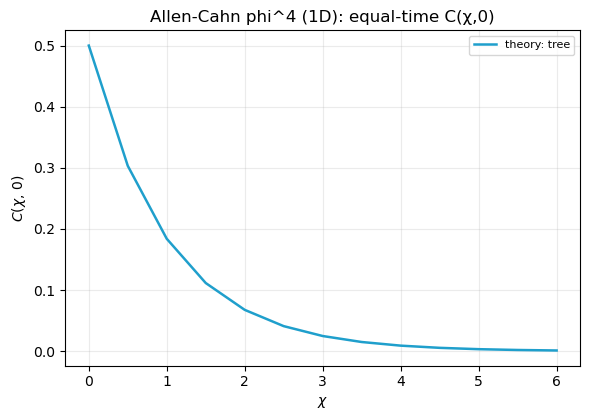

In [8]:
spatial_model = (
    SpatialTheoryBuilder('Allen-Cahn phi^4 (1D)', n_populations=0)
    .physical_field('phi', spatial_dim=1, description='order parameter')
    .parameter('mu',  default=1.0, domain='positive')
    .parameter('D',   default=1.0, domain='positive')
    .parameter('lam', default=0.1, domain='positive')
    .parameter('T',   default=1.0, domain='positive')      # noise strength  <eta eta> = 2 T delta delta
    # scalar action (no [i] / sum); diffusion enters as -D*Laplacian in the EOM operator
    .set_action_text('phit*((Dt + mu - D*Laplacian)*phi + lam*phi^3) - T*phit^2')
    .equation(lhs='(Dt + mu - D*Laplacian)*phi', rhs='-lam*phi^3')
    .boundary('infinite')
    .build()
)
dd.describe_model(spatial_model);

spatial_cfg = dd.Config(
    k=2, max_ell=0,
    external_fields=[('dphi', 1), ('dphi', 1)],   # the phi-fluctuation on both legs
    chi_grid=(0.0, 6.0, 13),                       # equal-time C(chi, 0) over chi in [0, 6]
)
spatial_res = dd.run(spatial_model, spatial_cfg, None)
print(dd.summary(spatial_res))

fig = dd.plot_cumulant(spatial_res, spatial_cfg, spatial_model)
plt.show()

---
## Appendix B — action cheat-sheet & where to go next

**Operators & syntax**

| token | meaning |
|---|---|
| `Dt` | time derivative $\partial_t$ |
| `Laplacian` | $\nabla^{2}$ (spatial theories only) |
| `^` | power, e.g. `x[i]^3` |
| `x[i]`, `xt[i]` | the field `x` and its response partner, at population index `i` |
| `sum(expr for i in pop)` | sum over a population (drop it for a scalar spatial field) |

**Common building blocks**

- **White noise** $\langle\xi\xi\rangle = 2D\,\delta$ → add `- D*xt^2` (one per noise source).
- **Cross-correlated noise** between fields $a,b$ → add `- 2*rho*sqrt(Ta*Tb)*at*bt`.
- **Two coupled fields** → declare each with `.physical_field`, then put the coupling in the
  drift, e.g. `at*( (Dt+mua)*a + g*b )` and `bt*( (Dt+mub)*b - h*a )`.
- **Multi-population** → `.population('E', size=N)`, index with `[i]`, and write inner sums
  like `sum(w[i,j]*n[j] for j in E)`; give matrix parameters `indexed_by=['E','E']`.
- **Memory / colored noise** → declare a kernel with `.define_kernel(...)` (see
  `theories/my_stochastic_theory.theory.py` for a worked multi-population example).

**Where to go next**

- **Run a saved theory** — [`theory_runner.ipynb`](theory_runner.ipynb) loads any
  `theories/*.theory.py` and runs it with one `dd.Config`.
- **Build by form** — [`theory_builder.ipynb`](theory_builder.ipynb) is the point-and-click
  version of this notebook; it writes a `.theory.py` file for you.
- **See it validated** — [`examples/`](examples/) has one notebook per pipeline capability,
  each overlaying theory against an independent simulation.

**Save your inline theory as a reusable file.** Wrap the builder call in a `build()` function
in `theories/<your-name>.theory.py` and add module-level `DEFAULT_FUNDAMENTAL = {...}` (numeric
defaults) and `METADATA = {...}` (e.g. `k_default`, `tau_max`). Copy the structure of any file
in `theories/` — for instance `theories/ou_quartic.theory.py`, which is exactly the §3 model.
Then it loads by name in the runner.